Shape: (284807, 31)

Sample Data:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

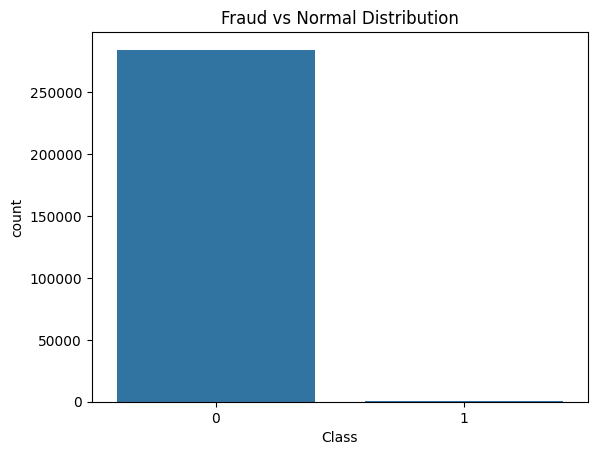

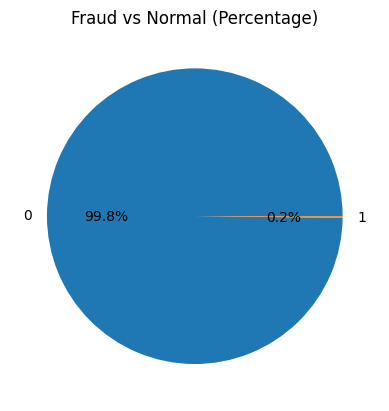


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

New Dataset Shape After Synthetic Injection: (286807, 30)

Confusion Matrix:
[[256700  27615]
 [  1426   1066]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.95    284315
           1       0.04      0.43      0.07      2492

    accuracy                           0.90    286807
   macro avg       0.52      0.67      0.51    286807
weighted avg       0.99      0.90      0.94    286807



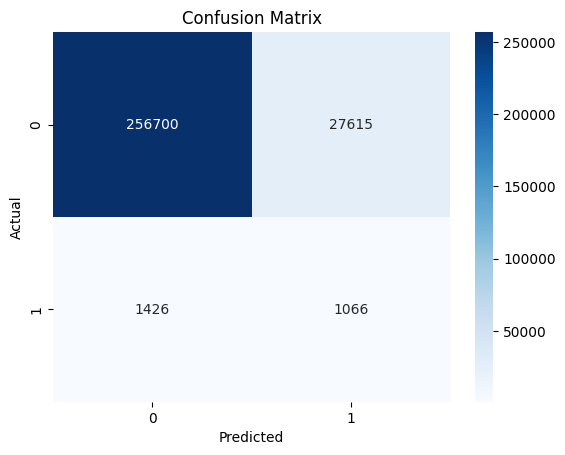

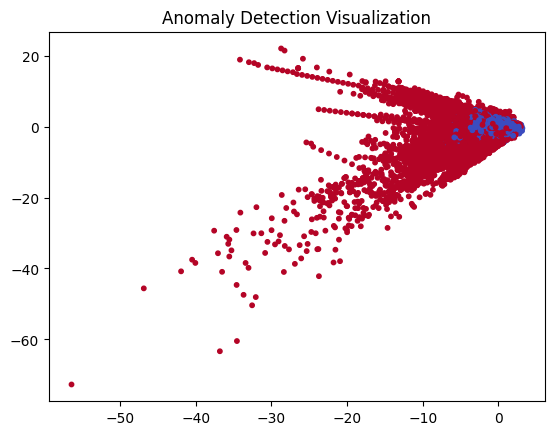

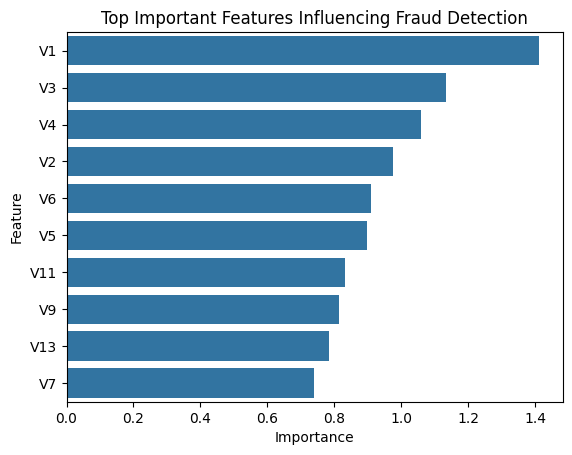


Sample Risk Scores:
   Risk Score  Class
0    7.839832      0
1    2.873596      0
2   23.198211      0
3    8.890425      0
4    5.662559      0


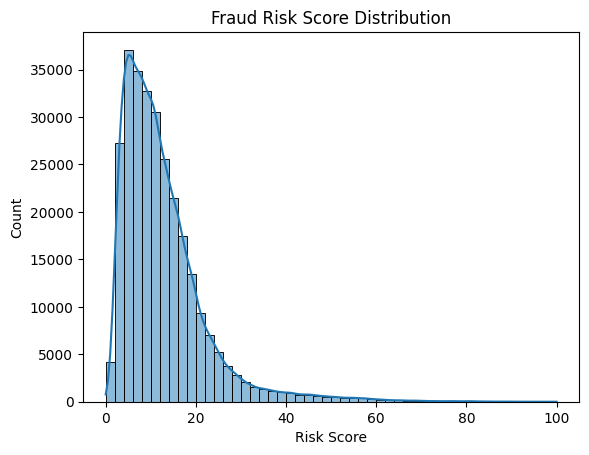


===== FINAL PREDICTION =====
Prediction: ✅ NORMAL
Risk Score: 93.06%

System Insight: High risk scores indicate anomalous behavior patterns similar to synthetic identities.


In [11]:
# Synthetic Identity Fraud Detection System
# Detecting synthetic identities using anomaly detection and risk scoring

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('/content/creditcard.csv')
df.columns = ['Time'] + [f'V{i}' for i in range(1,29)] + ['Amount','Class']

print("Shape:", df.shape)
print("\nSample Data:")
print(df.head())

print("\nDataset Info:")
df.info()

plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Distribution")
plt.show()

plt.figure()
df['Class'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Fraud vs Normal (Percentage)")
plt.ylabel("")
plt.show()

print("\nClass Distribution:")
print(df['Class'].value_counts())

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

df = df.drop(['Time'], axis=1)

synthetic = df[df['Class'] == 0].sample(2000).copy()

synthetic['Amount'] = synthetic['Amount'] * np.random.uniform(2, 5, size=len(synthetic))

for col in synthetic.columns[:-1]:
    synthetic[col] += np.random.normal(0, 0.5, size=len(synthetic))

synthetic['Class'] = 1

df_aug = pd.concat([df, synthetic])

print("\nNew Dataset Shape After Synthetic Injection:", df_aug.shape)

X = df_aug.drop('Class', axis=1)
y = df_aug['Class']

model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X)

preds = model.predict(X)
preds = np.where(preds == -1, 1, 0)

print("\nConfusion Matrix:")
print(confusion_matrix(y, preds))

print("\nClassification Report:")
print(classification_report(y, preds))

cm = confusion_matrix(y, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure()
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=preds, cmap='coolwarm', s=10)
plt.title("Anomaly Detection Visualization")
plt.show()

feature_importance = np.mean(np.abs(X), axis=0)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top Important Features Influencing Fraud Detection")
plt.show()

scores = model.decision_function(X)

risk_score = (1 - scores)
risk_score = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())
risk_score = risk_score * 100

df_aug['Risk Score'] = risk_score

print("\nSample Risk Scores:")
print(df_aug[['Risk Score', 'Class']].head())

plt.figure()
sns.histplot(df_aug['Risk Score'], bins=50, kde=True)
plt.title("Fraud Risk Score Distribution")
plt.show()

sample = X.iloc[0].values.reshape(1, -1)

prediction = model.predict(sample)
prediction = 1 if prediction[0] == -1 else 0

score = model.decision_function(sample)
risk = (1 - score[0])
risk = max(0, min(100, risk * 100))

print("\n===== FINAL PREDICTION =====")
print(f"Prediction: {'🚨 FRAUD' if prediction == 1 else '✅ NORMAL'}")
print(f"Risk Score: {float(risk):.2f}%")

print("\nSystem Insight: High risk scores indicate anomalous behavior patterns similar to synthetic identities.")